In [40]:
%matplotlib inline

from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import pandas as pd
import matplotlib.pyplot as plt
import os

# Chargement des tweets nettoyés
df = pd.read_csv("../data/silver/tweets_cleaned_1.csv")
texts = df["clean_text"].dropna().tolist()

In [ ]:
from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans
from openai import OpenAI
import pandas as pd

# 1. Embedding
model = SentenceTransformer("all-MiniLM-L6-v2")
embeddings = model.encode(df["clean_text"].tolist(), show_progress_bar=True)

# 2. Clustering
kmeans = KMeans(n_clusters=6)
df["cluster"] = kmeans.fit_predict(embeddings)

# 3. Résumé de chaque cluster avec OpenAI
from openai import OpenAI
client = OpenAI(api_key="sk-...")
for i in df["cluster"].unique():
    texts = df[df["cluster"] == i]["clean_text"].sample(10).tolist()
    prompt = f"""Tu es un analyste réseaux sociaux. Voici 10 tweets :
{chr(10).join(['- ' + t for t in texts])}

Quelle est la thématique commune ?"""
    response = client.chat.completions.create(
        model="gpt-4",
        messages=[{"role": "user", "content": prompt}]
    )
    print(f"Cluster {i} 🔍 : {response.choices[0].message.content}")


Your max_length is set to 20, but your input_length is only 13. Since this is a summarization task, where outputs shorter than the input are typically wanted, you might consider decreasing max_length manually, e.g. summarizer('...', max_length=6)
Your max_length is set to 20, but your input_length is only 13. Since this is a summarization task, where outputs shorter than the input are typically wanted, you might consider decreasing max_length manually, e.g. summarizer('...', max_length=6)
Your max_length is set to 20, but your input_length is only 12. Since this is a summarization task, where outputs shorter than the input are typically wanted, you might consider decreasing max_length manually, e.g. summarizer('...', max_length=6)
Your max_length is set to 20, but your input_length is only 9. Since this is a summarization task, where outputs shorter than the input are typically wanted, you might consider decreasing max_length manually, e.g. summarizer('...', max_length=4)
Your max_leng

KeyboardInterrupt: 

In [48]:
# Embedding sémantique
model = SentenceTransformer("all-MiniLM-L6-v2")
embeddings = model.encode(texts, show_progress_bar=True)

k = 6  # ou HDBSCAN si tu veux auto-estimation
kmeans = KMeans(n_clusters=k, random_state=0).fit(embeddings)


Batches: 100%|██████████| 95/95 [01:04<00:00,  1.48it/s]


In [52]:
df["cluster"] = kmeans.labels_

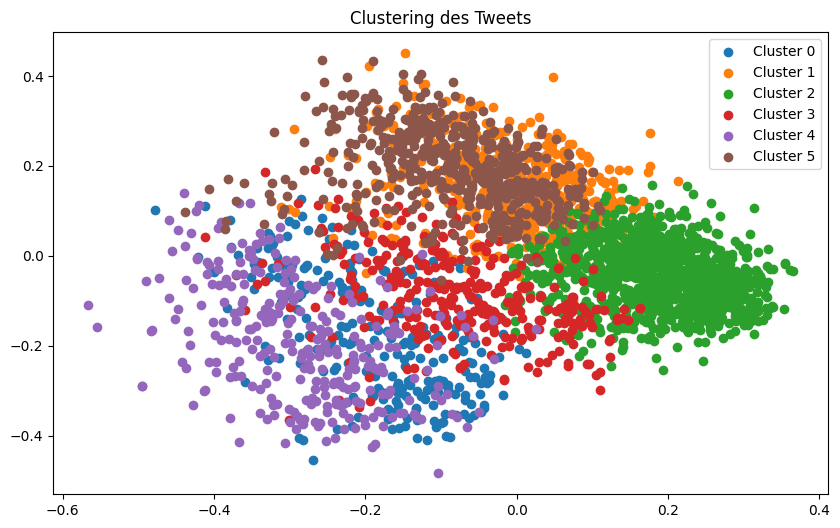

In [53]:
# Visualisation
pca = PCA(n_components=2)
coords = pca.fit_transform(embeddings)
df["x"] = coords[:,0]
df["y"] = coords[:,1]

plt.figure(figsize=(10,6))
for i in range(k):
    subset = df[df["cluster"] == i]
    plt.scatter(subset["x"], subset["y"], label=f"Cluster {i}")
plt.legend()
plt.title("Clustering des Tweets")
plt.show()


In [54]:
for i in df["cluster"].unique():
    print(f"\n📌 Cluster {i} :")
    display(df[df["cluster"] == i]["clean_text"].sample(5, random_state=42))


📌 Cluster 1 :


1673    mon courrier a fait réagir cest biennpar contr...
457     cest sérieux votre service client qui réponds pas
1816    allô et pas dinternet depuis ce matin votre bo...
952     oui mais jai appeler pour avoir des infos etc ...
636     vous êtes des escrocs incompétents free demand...
Name: clean_text, dtype: object


📌 Cluster 3 :


759     après des années de foutage de gueule chez ora...
1120    je suis surpris dapprendre que je dois 50 euro...
2756    bon cela fait 1 moi que je suis dans mon appar...
1100    jai entamé le déménagement de ma fibre il y a ...
2573    toujours en attente depuis trois mois de la ré...
Name: clean_text, dtype: object


📌 Cluster 2 :


...

2795    cest normal il débranche les autres abonnés de...
522     ça ne vous dérange pas dannuler le rdv avec vo...
2063    jai voulu prendre lultra pour le wifi 7 je reg...
576     remettez la wifi pitié je suis au chapitre 6 d...
2667    bon on en est au 3eme jour de panne la on fait...
Name: clean_text, dtype: object


📌 Cluster 4 :


2792    bonjour sur la freebox pop player de mon père ...
1538    voilà une fois de plus en plein film plus de r...
812     bonjour freebox votre répéteur wi fi coute 20 ...
800     je viens de souscrire à une offre freebox en r...
2700    ouais enfin pendant ce temps jattends toujours...
Name: clean_text, dtype: object


📌 Cluster 0 :


400     même sans bras et sans jambes il serait plus r...
2270    laisser galérer ses clients pendant un déménag...
2647    réparée ma box svp ça fait 1 semaine elle wi f...
2340    ya pas à avoir une box qui se deco toute les 5...
2589    bon cest possible davoir internet nan parce qu...
Name: clean_text, dtype: object